#### **PROYEK KLASIFIKASI GAMBAR - Cat and Dog Dataset**

Proyek ini mengklasifikasikan gambar kucing vs anjing menggunakan dataset Cat and Dog dari Kaggle, Transfer Learning, dengan skrip yang disederhanakan.

**Kriteria Proyek:**
1.  Menggunakan dataset Cat and Dog dari Kaggle (>10.000 gambar).
2.  Dataset diakses langsung di Colab tanpa manual download.
3.  Menggunakan struktur loading data via `ImageDataGenerator` dari direktori.
4.  Menggunakan pendekatan Transfer Learning.
5.  Target akurasi tinggi pada tugas klasifikasi biner ini.
6.  Membuat plot akurasi dan loss model.
7.  Menyimpan model dalam format SavedModel, TF-Lite, dan TFJS.

## **Setup Colab dan Data Loading**

**Instalasi Library yang Dibutuhkan**

In [2]:
!pip install kaggle tensorflowjs matplotlib requests Pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 4.0 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 24.2
    Uninstalling packaging-24.2:
      Successfully uninstalled packaging-24.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-cloud-bigquery 3.31.0 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.


**Konfigurasi Kaggle**

In [3]:
# Buat direktori
!mkdir -p ~/.kaggle

In [4]:
!cp kaggle.json ~/.kaggle/

In [5]:
# Beri izin akses
!chmod 600 ~/.kaggle/kaggle.json

**Unduh Dataset**


Mengunduh dan mengekstrak dataset langsung di Colab.

In [6]:
# Hapus folder sampel bawaan jika ada
!rm -r sample_data || true

In [47]:
# Nama dataset di Kaggle
KAGGLE_DATASET_NAME = 'tongpython/cat-and-dog'

In [48]:
import os
DATA_DIR = '/content/cat_dog_kaggle_data'
os.makedirs(DATA_DIR, exist_ok=True)

In [49]:
# Unduh dan ekstrak file zip dataset
!kaggle datasets download -d {KAGGLE_DATASET_NAME} -p {DATA_DIR} --unzip

Dataset URL: https://www.kaggle.com/datasets/tongpython/cat-and-dog
License(s): CC0-1.0


**Import Library**

In [50]:
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [51]:
base_dir = DATA_DIR

In [52]:
# Direktori training dan validation/test
train_dir = os.path.join(base_dir, 'training_set')
validation_dir = os.path.join(base_dir, 'test_set')

In [53]:
# Parameter Gambar dan Batch Size
IMG_WIDTH = 150
IMG_HEIGHT = 150
IMG_SHAPE = (IMG_HEIGHT, IMG_WIDTH, 3)
BATCH_SIZE = 32
NUM_CLASSES = 1

In [56]:
print(f"Image Size: {IMG_HEIGHT}x{IMG_WIDTH}")

Image Size: 150x150


## **Data Augmentation**

Menggunakan `ImageDataGenerator` dengan `validation_split` untuk membagi data dan melakukan augmentasi.

In [57]:
# Training Data Generator
train_image_generator = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [58]:
# Validation Data Generator
validation_image_generator = ImageDataGenerator(rescale=1./255)

In [59]:
# Flow data dari direktori untuk training
train_data_gen = train_image_generator.flow_from_directory(
    directory=train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Found 8005 images belonging to 1 classes.


In [60]:
# Flow data dari direktori untuk validation
val_data_gen = validation_image_generator.flow_from_directory(
    directory=validation_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Found 2023 images belonging to 1 classes.


In [61]:
# Ambil jumlah gambar dari generators untuk menghitung steps_per_epoch
total_train = train_data_gen.samples
total_validation = val_data_gen.samples

In [62]:
print(f"\nTotal gambar training: {total_train}")
print(f"Total gambar validation: {total_validation}")
print(f"Mapping kelas: {train_data_gen.class_indices}")


Total gambar training: 8005
Total gambar validation: 2023
Mapping kelas: {'training_set': 0}


In [63]:
# Hitung steps per epoch
steps_per_epoch = total_train // BATCH_SIZE
validation_steps = total_validation // BATCH_SIZE

In [64]:
# Tambahkan 1 langkah jika ada sisa data yang kurang dari batch_size
if total_train % BATCH_SIZE != 0: steps_per_epoch += 1
if total_validation % BATCH_SIZE != 0: validation_steps += 1

In [65]:
# Pastikan validation_steps minimal 1 jika ada data validasi
if validation_steps == 0 and total_validation > 0: validation_steps = 1

## **Transfer Learning**

Menggunakan MobileNetV2 pre-trained dan menambahkan layer untuk klasifikasi multi-kelas.

In [66]:
# Load Base Model MobileNetV2
base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE,
                                               include_top=False,
                                               weights='imagenet')

<ipython-input-66-c4321a37f19b>:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE,


In [67]:
# Bekukan base model
base_model.trainable = False

base_model.summary()

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 75, 75,    │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 75, 75,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 75, 75,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 75, 75,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 75, 75,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 75, 75,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 77, 77,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 38, 38,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 38, 38,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [68]:
# Buat model Sequential
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

**Kompilasi Model**

Kompilasi model untuk pelatihan awal (hanya layer yang baru ditambahkan).

In [69]:
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

**Callbacks**

In [70]:
CHECKPOINT_DIR = 'catdog_kaggle_checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
checkpoint_filepath_head = os.path.join(CHECKPOINT_DIR, 'best_model_head.keras')

callbacks_head = [
    EarlyStopping(monitor='val_loss', patience=10, verbose=1, restore_best_weights=True),
    ModelCheckpoint(filepath=checkpoint_filepath_head,
                    monitor='val_accuracy',
                    save_best_only=True,
                    verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=0.00001, verbose=1)
]

## **Training**

**Latih Layer Klasifikasi Baru (Head)**

In [72]:
EPOCHS_HEAD = 10
print(f"Steps per epoch: {steps_per_epoch}, Validation steps: {validation_steps}")

Steps per epoch: 251, Validation steps: 64


In [73]:
history_head = model.fit(
    train_data_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS_HEAD,
    validation_data=val_data_gen,
    validation_steps=validation_steps,
    callbacks=callbacks_head
)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 779ms/step - accuracy: 0.9939 - loss: 0.0154
Epoch 1: val_accuracy improved from -inf to 1.00000, saving model to catdog_kaggle_checkpoints/best_model_head.keras
251/251 ━━━━━━━━━━━━━━━━━━━━ 246s 954ms/step - accuracy: 0.9939 - loss: 0.0153 - val_accuracy: 1.0000 - val_loss: 8.7479e-05 - learning_rate: 1.0000e-04
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 890ms/step - accuracy: 1.0000 - loss: 1.1074e-04
Epoch 2: val_accuracy did not improve from 1.00000
251/251 ━━━━━━━━━━━━━━━━━━━━ 328s 1s/step - accuracy: 1.0000 - loss: 1.1064e-04 - val_accuracy: 1.0000 - val_loss: 2.7928e-05 - learning_rate: 1.0000e-04
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 765ms/step - accuracy: 1.0000 - loss: 4.3143e-05
Epoch 3: val_accuracy did not improve from 1.00000
251/251 ━━━━━━━━━━━━━━━━━━━━ 229s 912ms/step - accuracy: 1.0000 - loss: 4.3119e-05 - val_accuracy: 1.0000 - val_loss: 1.2053e-05 - learning_rate: 1.0000e-04
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 75

In [74]:
model.load_weights(checkpoint_filepath_head)

In [75]:
history_combined = history_head
epochs_range_combined = range(len(history_combined.history['accuracy']))
acc = history_combined.history['accuracy']
val_acc = history_combined.history['val_accuracy']
loss = history_combined.history['loss']
val_loss = history_combined.history['val_loss']

## **Model Evaluating**

**Plot Akurasi dan Loss**


Visualisasikan hasil pelatihan gabungan.

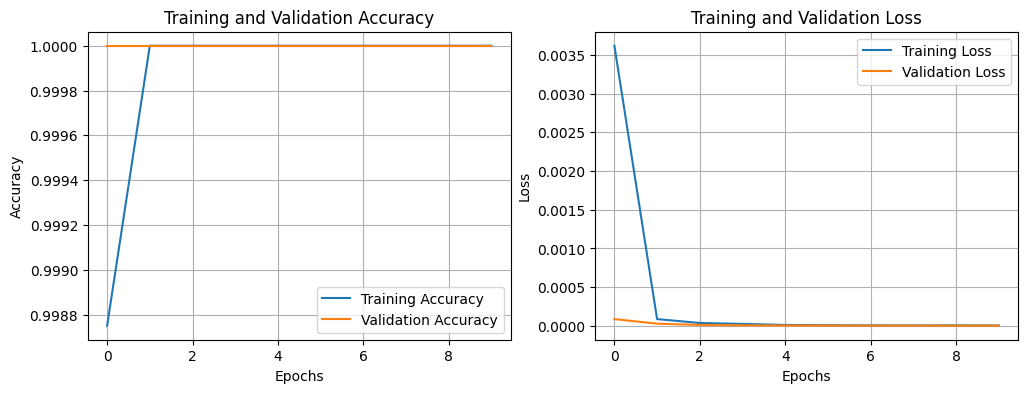

In [76]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range_combined, acc, label='Training Accuracy')
plt.plot(epochs_range_combined, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range_combined, loss, label='Training Loss')
plt.plot(epochs_range_combined, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)

plt.show()

**Evaluasi Akhir Model**


Evaluasi model terbaik menggunakan data validation (test set).

In [77]:
loss, accuracy = model.evaluate(val_data_gen, steps=validation_steps, verbose=1)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

64/64 ━━━━━━━━━━━━━━━━━━━━ 37s 574ms/step - accuracy: 1.0000 - loss: 7.6765e-05
Test Loss: 8.747876563575119e-05
Test Accuracy: 1.0


## **Saving Model**

In [78]:
import subprocess

MODEL_SAVE_BASE_DIR = 'catdog_kaggle_model_output'
os.makedirs(MODEL_SAVE_BASE_DIR, exist_ok=True)

SAVED_MODEL_DIR = os.path.join(MODEL_SAVE_BASE_DIR, 'saved_model')
TFLITE_MODEL_DIR = os.path.join(MODEL_SAVE_BASE_DIR, 'tflite_model')
TFJS_MODEL_DIR = os.path.join(MODEL_SAVE_BASE_DIR, 'tfjs_model')

In [79]:
if os.path.exists(SAVED_MODEL_DIR): shutil.rmtree(SAVED_MODEL_DIR)
if os.path.exists(TFLITE_MODEL_DIR): shutil.rmtree(TFLITE_MODEL_DIR)
if os.path.exists(TFJS_MODEL_DIR): shutil.rmtree(TFJS_MODEL_DIR)

# Buat direktori output
os.makedirs(SAVED_MODEL_DIR, exist_ok=True)
os.makedirs(TFLITE_MODEL_DIR, exist_ok=True)
os.makedirs(TFJS_MODEL_DIR, exist_ok=True)

**SavedModel**

In [80]:
try:
    tf.saved_model.save(model, SAVED_MODEL_DIR)
    print(f" SavedModel: {os.path.abspath(SAVED_MODEL_DIR)}")
except Exception as e:
    print(f"\nError: {e}")

 SavedModel: /content/catdog_kaggle_model_output/saved_model


**TF-Lite**

In [81]:
try:
    converter = tf.lite.TFLiteConverter.from_saved_model(SAVED_MODEL_DIR)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]

    tflite_model = converter.convert()

    tflite_model_path = os.path.join(TFLITE_MODEL_DIR, 'model.tflite')
    with open(tflite_model_path, 'wb') as f:
        f.write(tflite_model)

    print(f"TF-Lite: {os.path.abspath(tflite_model_path)}")
except Exception as e:
     print(f"\nError: {e}")

TF-Lite: /content/catdog_kaggle_model_output/tflite_model/model.tflite


**TFJS**

In [82]:
try:
    saved_model_dir_tfjs = SAVED_MODEL_DIR

    try:
         output_node_name = model.layers[-1].name + '/' + model.layers[-1].activation.__name__
         print(f"Output node name: {output_node_name}")
    except Exception as e:
         print(f"Tidak dapat mendeteksi nama output node secara otomatis: {e}")
         output_node_name = 'dense_1/Sigmoid'


    process = subprocess.run(
        ['tensorflowjs_converter',
         '--input_format', 'tf_saved_model',
         '--output_node_names', output_node_name,
         os.path.abspath(saved_model_dir_tfjs),
         os.path.abspath(TFJS_MODEL_DIR)],
        capture_output=True,
        text=True,
        check=True
    )

    print("\nTFJS Converter Output:")
    print(process.stdout)
    print(process.stderr)

    # Verifikasi file model.json
    model_json_path = os.path.join(TFJS_MODEL_DIR, 'model.json')
    if os.path.exists(model_json_path):
        print(f"\nTFJS: {os.path.abspath(TFJS_MODEL_DIR)}")
        print(f"File model.json: {os.path.abspath(model_json_path)}")
    else:
        print("\n Konversi TFJS selesai, namun file model.json tidak ditemukan di direktori output.")

except FileNotFoundError:
     print("\n Error: 'tensorflowjs_converter' tidak ditemukan.")
except subprocess.CalledProcessError as e:
     print(f"\n Gagal menjalankan tensorflowjs_converter: {e}")
     print("   Return Code:", e.returncode)
     print("   Stderr:", e.stderr)
     print("   Stdout:", e.stdout)
except Exception as e:
     print(f"\n Terjadi error tidak terduga saat konversi TFJS: {e}")

Output node name: dense_3/sigmoid

TFJS Converter Output:

2025-04-30 22:13:17.407028: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746051197.442701   97888 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746051197.453953   97888 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
🌲 Try https://ydf.readthedocs.io, the successor of TensorFlow Decision Forests with more features and faster training!
2025-04-30 22:13:27.948665: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
I0000 00:00:1746051209.691895   97888 devices.cc:67] Number of eligible GPUs 